In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/processed/aapl_features.csv", index_col="Date", parse_dates=True)
df['next_close'] = df['Close'].shift(-1)
df['target'] = (df['next_close'] > df['Close']).astype(int)
df['next_day_return'] = (df['next_close'] - df['Close']) / df['Close']

feature_cols = ['daily_return', 'ma_20', 'volatility_20', 'momentum_10']
model_df = df.dropna(subset=feature_cols + ['next_close'])

X = model_df[feature_cols]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)
print(predictions[:10])


[1 1 1 1 1 1 1 1 1 1]


In [4]:
test_returns = model_df.loc[X_test.index, 'next_day_return']

backtest_df = pd.DataFrame({
    'prediction': predictions,
    'actual_return': test_returns.values
}, index=X_test.index)

backtest_df.head()


,prediction,actual_return
Date,,
2025-07-16 00:00:00-04:00,1,-0.000666
2025-07-17 00:00:00-04:00,1,0.005523
2025-07-18 00:00:00-04:00,1,0.006156
2025-07-21 00:00:00-04:00,1,0.009036
2025-07-22 00:00:00-04:00,1,-0.001166


In [5]:
backtest_df['strategy_return'] = backtest_df['prediction'] * backtest_df['actual_return']


<Axes: title={'center': 'Strategy vs Buy & Hold'}, xlabel='Date'>

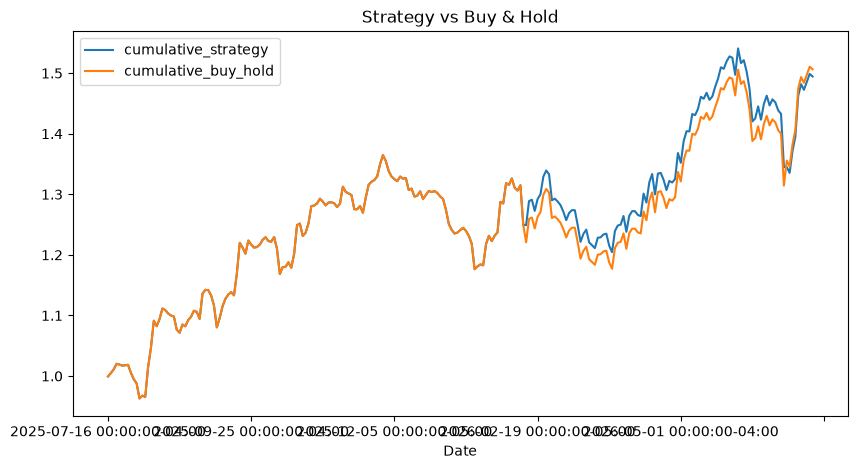

In [6]:
backtest_df['cumulative_strategy'] = (1 + backtest_df['strategy_return']).cumprod()
backtest_df['cumulative_buy_hold'] = (1 + backtest_df['actual_return']).cumprod()

backtest_df[['cumulative_strategy', 'cumulative_buy_hold']].plot(figsize=(10, 5), title="Strategy vs Buy & Hold")


In [7]:
final_strategy = backtest_df['cumulative_strategy'].iloc[-1]
final_buy_hold = backtest_df['cumulative_buy_hold'].iloc[-1]

print(f"Strategy total return: {(final_strategy - 1) * 100:.2f}%")
print(f"Buy & Hold total return: {(final_buy_hold - 1) * 100:.2f}%")


Strategy total return: 49.45%
Buy & Hold total return: 50.63%


In [8]:
transaction_cost = 0.001  # 0.1% per trade

backtest_df['trade'] = backtest_df['prediction'].diff().fillna(0) != 0
backtest_df['strategy_return_after_costs'] = backtest_df['strategy_return'] - (backtest_df['trade'] * transaction_cost)

backtest_df['cumulative_strategy_after_costs'] = (1 + backtest_df['strategy_return_after_costs']).cumprod()

print("Number of trades:", backtest_df['trade'].sum())
print(f"Strategy return (no costs): {(backtest_df['cumulative_strategy'].iloc[-1] - 1) * 100:.2f}%")
print(f"Strategy return (with costs): {(backtest_df['cumulative_strategy_after_costs'].iloc[-1] - 1) * 100:.2f}%")


Number of trades: 4
Strategy return (no costs): 49.45%
Strategy return (with costs): 48.86%
